# Mini Project 2

**2025 Introduction to Quantiative Methods in Finance**

**The Erdös Institute**


###  Hypothesis Testing of Standard Assumptions Theoretical Financial Mathematics

In the theory of mathematical finance, it is common to assume the log returns of a stock/index are normally distributed.


Investigate if the log returns of stocks or indexes of your choosing are normally distributed. Some suggestions for exploration include:

    1) Test if there are period of times when the log-returns of a stock/index have evidence of normal distribution.
    
    2) Test if removing extremal return data creates a distribution with evidence of being normal.
    
    3) Create a personalized portfolio of stocks with historical log return data that is normally distributed.
    
    4) Test if the portfolio you created in the first mini-project has significant periods of time with evidence of normally distributed log returns.
    
    5) Gather x-number of historical stock data and just perform a normality test on their log return data to see if any of the stocks exhibit evidence of log returns that are normally distributed.

In [1]:
# Mini Project 2 - Log Return Normality & VaR Analysis
# Author: Yichen Li

# Import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, jarque_bera, norm
from statsmodels.stats.diagnostic import normal_ad
import warnings
warnings.filterwarnings("ignore")

In [7]:
# Define high-volatility portfolio from Project 1
high_vol_stocks = ['TSLA', 'NVDA', 'GOOGL', 'AMZN', 'MSFT']
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) 

In [9]:
# Download daily close prices
data = yf.download(high_vol_stocks, start='2023-06-01', end='2024-06-01')
close_prices = data['Close']

[*********************100%***********************]  5 of 5 completed


In [11]:
# Compute daily log returns
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

# Calculate portfolio returns
portfolio_returns = log_returns @ weights
portfolio_returns.name = 'High Volatility Portfolio Return'

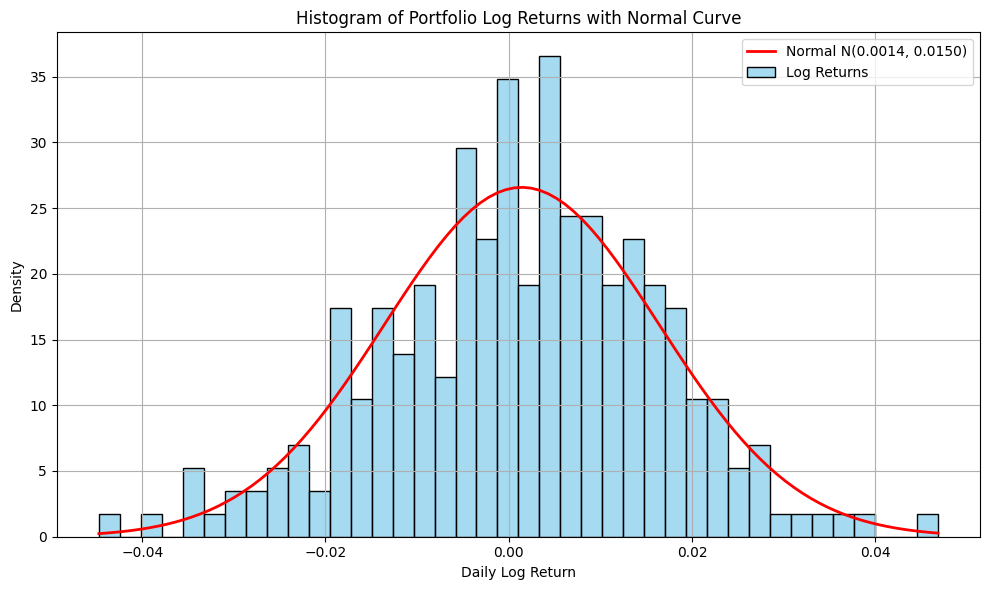

In [13]:
# Plot histogram with normal curve overlay
plt.figure(figsize=(10, 6))
sns.histplot(portfolio_returns, bins=40, stat='density', color='skyblue', label='Log Returns')
mu, sigma = portfolio_returns.mean(), portfolio_returns.std()
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'Normal N({mu:.4f}, {sigma:.4f})')
plt.title('Histogram of Portfolio Log Returns with Normal Curve')
plt.xlabel('Daily Log Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# Perform normality tests
shapiro_result = shapiro(portfolio_returns)
jb_result = jarque_bera(portfolio_returns)
ad_stat, ad_p = normal_ad(portfolio_returns)

# Print results
print("Normality Test Results:")
print(f"Shapiro-Wilk: W = {shapiro_result[0]:.4f}, p = {shapiro_result[1]:.4f}")
print(f"Jarque-Bera : JB = {jb_result[0]:.4f}, p = {jb_result[1]:.4f}")
print(f"Anderson-Darling A² = {ad_stat:.4f}\n")

Normality Test Results:
Shapiro-Wilk: W = 0.9960, p = 0.7783
Jarque-Bera : JB = 1.7041, p = 0.4265
Anderson-Darling A² = 0.3290



In [22]:
# Compute Parametric VaR and CVaR at 95% confidence level
confidence = 0.95
z_score = norm.ppf(1 - confidence)
VaR = -mu + z_score * sigma
CVaR = -mu + sigma * norm.pdf(z_score) / (1 - confidence)

print(f"Parametric VaR (95% confidence): {VaR:.4f}")
print(f"Parametric CVaR (95% confidence): {CVaR:.4f}")

Parametric VaR (95% confidence): -0.0261
Parametric CVaR (95% confidence): 0.0295


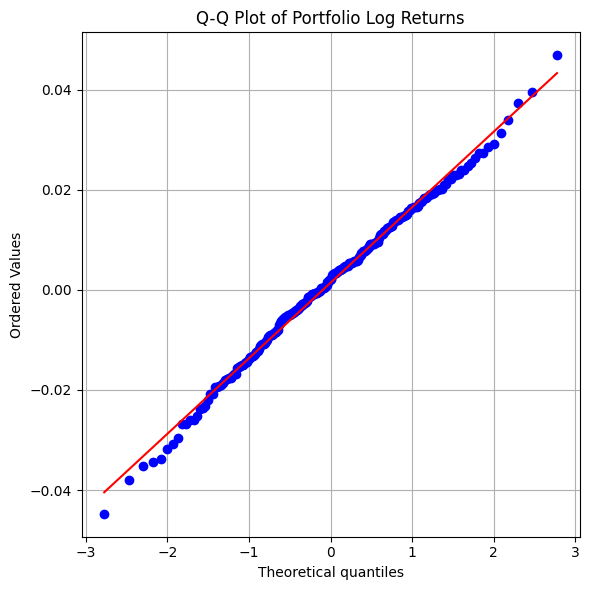

In [26]:
import scipy.stats as stats

# Q-Q Plot (Quantile-Quantile Plot)
plt.figure(figsize=(6, 6))
stats.probplot(portfolio_returns, dist="norm", plot=plt)
plt.title("Q-Q Plot of Portfolio Log Returns")
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
from scipy.stats import skew, kurtosis

# Skewness & Kurtosis 
skew_val = skew(portfolio_returns)
kurt_val = kurtosis(portfolio_returns, fisher=False)  # use Pearson's definition

print(f"Skewness: {skew_val:.4f}")
print(f"Kurtosis: {kurt_val:.4f}")


Skewness: -0.1807
Kurtosis: 3.1799


In [30]:
print(portfolio_returns.describe())

count    251.000000
mean       0.001423
std        0.015010
min       -0.044729
25%       -0.008386
50%        0.002070
75%        0.011858
max        0.046853
Name: High Volatility Portfolio Return, dtype: float64


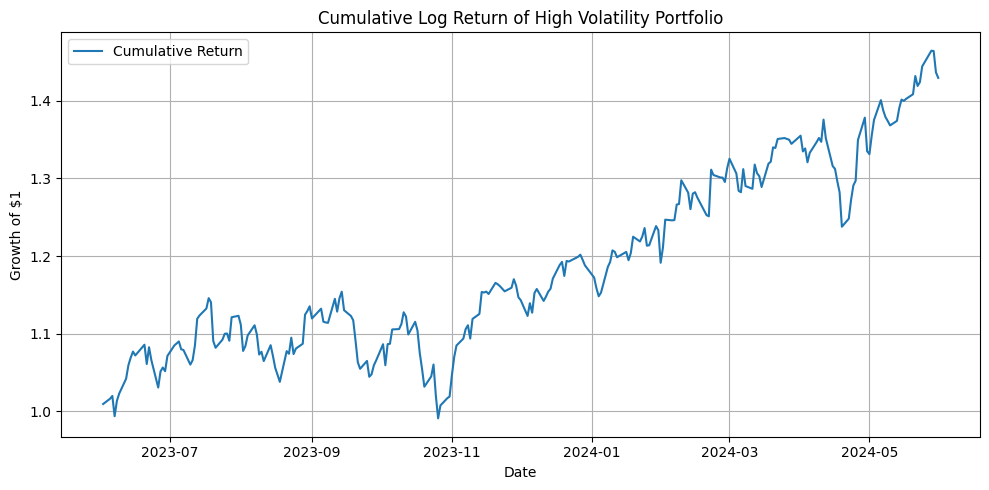

In [32]:
cumulative_returns = np.exp(portfolio_returns.cumsum())

# Cumulative Return
plt.figure(figsize=(10, 5))
plt.plot(cumulative_returns, label='Cumulative Return')
plt.title("Cumulative Log Return of High Volatility Portfolio")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


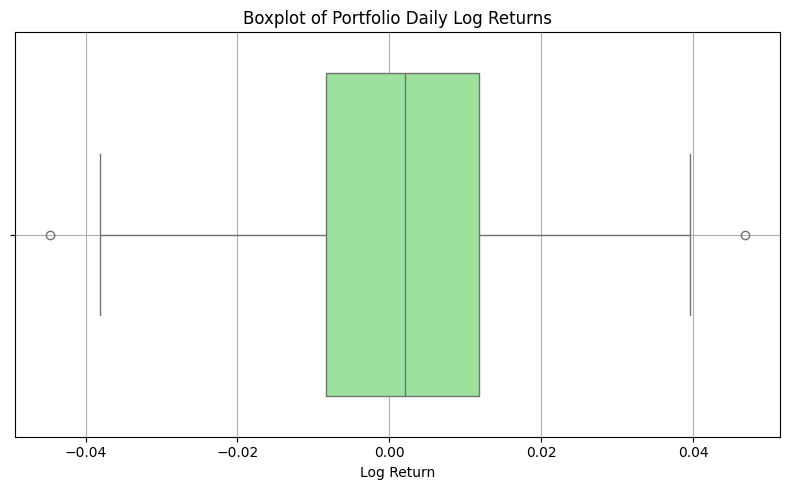

In [36]:
# Return Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=portfolio_returns, color='lightgreen')
plt.title("Boxplot of Portfolio Daily Log Returns")
plt.xlabel("Log Return")
plt.grid(True)
plt.tight_layout()
plt.show()


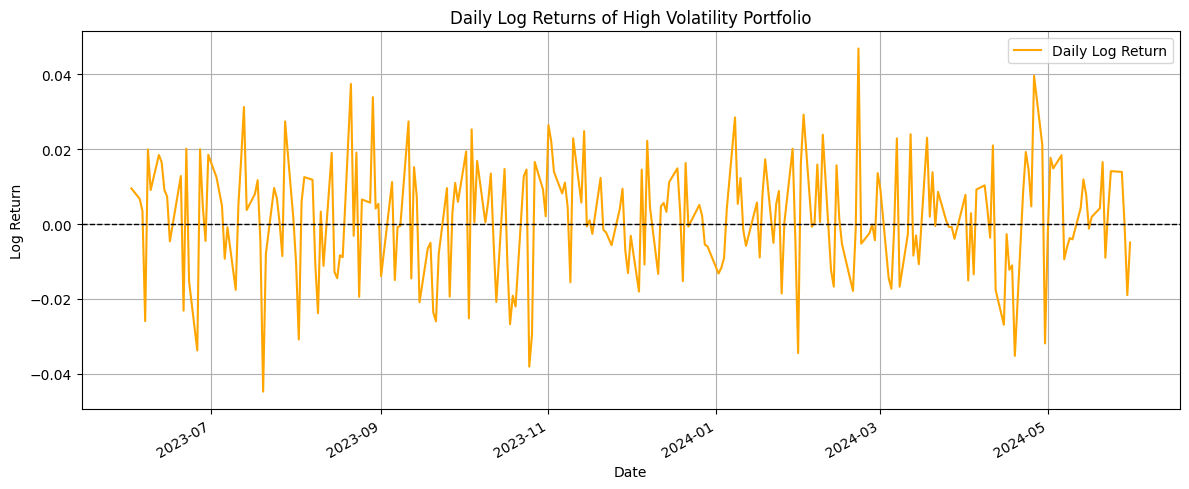

In [38]:
# Return Time Series Plot
plt.figure(figsize=(12, 5))
portfolio_returns.plot(color='orange', label='Daily Log Return')
plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.title("Daily Log Returns of High Volatility Portfolio")
plt.ylabel("Log Return")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

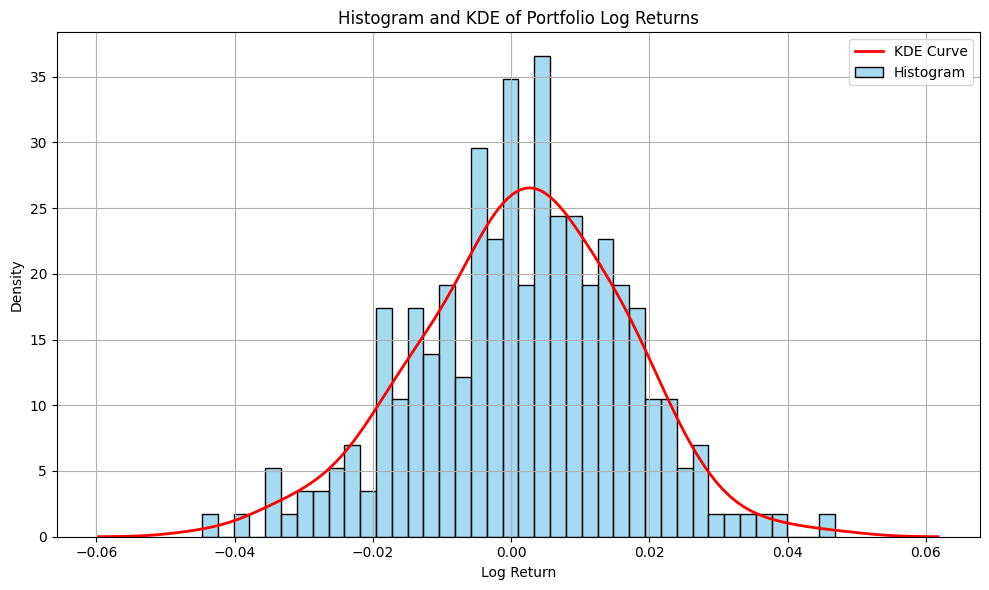

In [40]:
# Histogram with KDE Overlay
plt.figure(figsize=(10, 6))
sns.histplot(portfolio_returns, bins=40, stat='density', color='skyblue', label='Histogram')
sns.kdeplot(portfolio_returns, color='red', linewidth=2, label='KDE Curve')
plt.title("Histogram and KDE of Portfolio Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

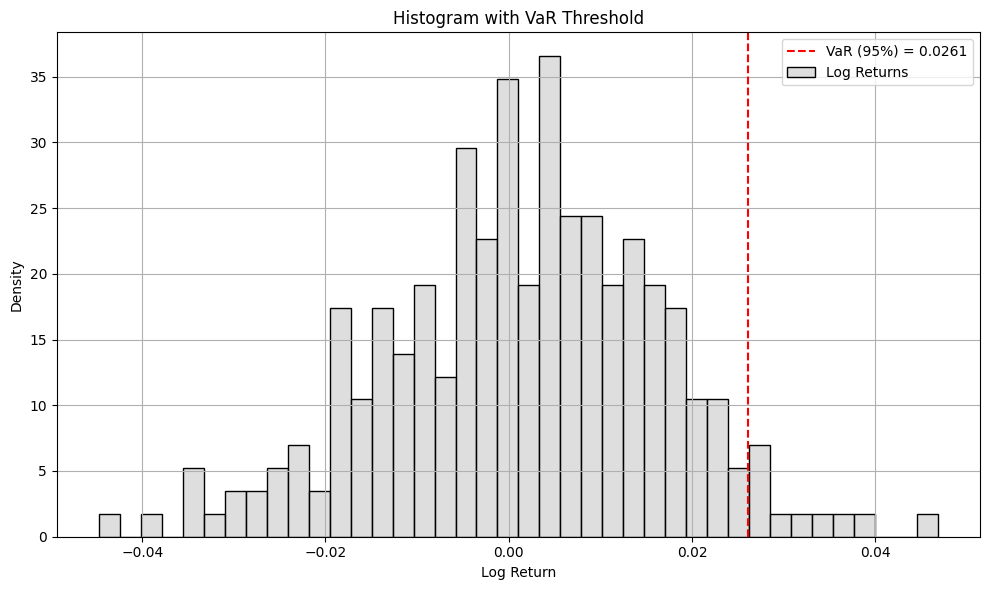

In [44]:
#  Histogram + VaR Threshold Line
plt.figure(figsize=(10, 6))
sns.histplot(portfolio_returns, bins=40, stat='density', color='lightgray', label='Log Returns')
plt.axvline(-VaR, color='red', linestyle='--', label=f'VaR (95%) = {-VaR:.4f}')
plt.title("Histogram with VaR Threshold")
plt.xlabel("Log Return")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
print("Conclusion:")
if shapiro_result[1] < 0.05 or jb_result[1] < 0.05 or ad_stat > 0.752:  # A² > 0.752 means significant at 5%
    print("The portfolio returns do not follow a normal distribution (at 5% significance level).")
else:
    print("The portfolio returns appear to be normally distributed (at 5% significance level).")


Conclusion:
The portfolio returns appear to be normally distributed (at 5% significance level).
